In [ ]:


from google.colab import drive
drive.mount('/content/drive/', force_remount=True)


Mounted at /content/drive/


In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.fft import fft
from scipy.signal import find_peaks, butter, filtfilt
from scipy import stats
import matplotlib.pyplot as plt

def Convert_Uint_to_int(n):
    return n - 0x2000 if n >= 0x2000 else n

def get_BMI270_From_str(srt):
    if len(srt) != 36:
        return None
    data_Refr = "0123456789abcdefghijklmnopqrstuvwxyzABCDEF"
    out = []
    try:
        for i in range(12):
            part = srt[i*3:i*3+3]
            val = sum([data_Refr.index(part[j]) * (42 ** (2 - j)) for j in range(3)])
            out.append(Convert_Uint_to_int(val))
        return out
    except:
        return None

def get_BMI270_Readings_From_StringArray(StringArray):
    valid = [get_BMI270_From_str(s) for s in StringArray if s and len(s) == 36]
    valid = [v for v in valid if v is not None]
    return list(map(np.array, zip(*valid))) if valid else None

def Read_BMI270_String_Data(filepath):
    with open(filepath, 'r') as f:
        raw = f.read().strip()
    return [raw[i:i+36] for i in range(0, len(raw), 36) if len(raw[i:i+36]) == 36]

def butter_lowpass_filter(data, cutoff, fs, order):
    """Applies a Butterworth low-pass filter to the data."""  "1300 for sample rate"
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    # Get the filter coefficients
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    # Apply the filter
    y = filtfilt(b, a, data)
    return y


def extract_features(signal, name):

    if len(signal) == 0:
        # Return zero features for empty segments
        return {f'{name}_mean': 0, f'{name}_std': 0, f'{name}_rms': 0, f'{name}_fft1': 0, f'{name}_fft2': 0, f'{name}_energy': 0, f'{name}_peak_to_peak': 0, f'{name}_skewness': 0, f'{name}_kurtosis': 0}

    fft_vals = np.abs(fft(signal))

    features = {
        f'{name}_mean': np.mean(signal),
        f'{name}_std': np.std(signal),
        f'{name}_rms': np.sqrt(np.mean(signal**2)),
        f'{name}_fft1': fft_vals[1] if len(fft_vals) > 1 else 0,
        f'{name}_fft2': fft_vals[2] if len(fft_vals) > 2 else 0,
        f'{name}_energy': np.sum(fft_vals**2),
        f'{name}_peak_to_peak': np.ptp(signal),
        f'{name}_skewness': stats.skew(signal) if len(signal) > 2 else 0,
        f'{name}_kurtosis': stats.kurtosis(signal) if len(signal) > 3 else 0
    }

    return features

def robust_segment_5_reps(signal, min_distance=50, prominence_factor=0.3):

    # Strategy 1: Try with standard parameters
    signal_range = np.ptp(signal)
    prominence_threshold = signal_range * prominence_factor

    peaks, properties = find_peaks(
        signal,
        distance=min_distance,
        prominence=prominence_threshold,
        width=10
    )

    print(f"Strategy 1: Found {len(peaks)} peaks with prominence >= {prominence_threshold:.2f}")

    # Strategy 2: Lower prominence threshold
    if len(peaks) < 5:
        prominence_threshold = signal_range * 0.1
        peaks, properties = find_peaks(
            signal,
            distance=min_distance//2,
            prominence=prominence_threshold,
            width=5
        )
        print(f"Strategy 2: Found {len(peaks)} peaks with lower prominence >= {prominence_threshold:.2f}")

    # Strategy 3: Even more relaxed parameters
    if len(peaks) < 5:
        prominence_threshold = signal_range * 0.05
        peaks, properties = find_peaks(
            signal,
            distance=20,
            prominence=prominence_threshold,
            width=1
        )
        print(f"Strategy 3: Found {len(peaks)} peaks with very low prominence >= {prominence_threshold:.2f}")

    # Strategy 4: use local maxima if not enough
    if len(peaks) < 5:
        # Find all local maxima (peaks with height > neighbors)
        peaks = []
        for i in range(1, len(signal) - 1):
            if signal[i] > signal[i-1] and signal[i] > signal[i+1]:
                peaks.append(i)
        peaks = np.array(peaks)
        print(f"Strategy 4: Found {len(peaks)} local maxima")

    # Strategy 5: divide signal and find peak in each section
    if len(peaks) < 5:
        print("Strategy 5: Dividing signal into sections to find peaks")
        section_peaks = []
        signal_length = len(signal)

        # Divide into more sections than we need, then select best peaks
        num_sections = max(8, len(peaks) * 2)  # Create more sections
        section_size = signal_length // num_sections

        for i in range(num_sections):
            start_idx = i * section_size
            end_idx = (i + 1) * section_size if i < num_sections - 1 else signal_length

            if end_idx > start_idx:
                section = signal[start_idx:end_idx]
                if len(section) > 0:
                    local_peak_idx = np.argmax(section)
                    global_peak_idx = start_idx + local_peak_idx
                    section_peaks.append((global_peak_idx, signal[global_peak_idx]))

        # Sort by peak height and take the top peaks
        section_peaks.sort(key=lambda x: x[1], reverse=True)
        peaks = np.array([peak[0] for peak in section_peaks])
        print(f"Strategy 5: Generated {len(peaks)} section peaks")

    # Now select exactly 5 peaks
    if len(peaks) >= 5:
        if len(peaks) > 5:
            # If we have more than 5 peaks, select the 5 highest ones
            peak_heights = signal[peaks]
            top_5_indices = np.argsort(peak_heights)[-5:]
            selected_peaks = peaks[top_5_indices]
            selected_peaks = np.sort(selected_peaks)  # Sort by position
        else:
            selected_peaks = np.sort(peaks)
    else:
        print(f"Warning: Only found {len(peaks)} peaks, spreading them across signal")
        if len(peaks) == 0:
            selected_peaks = np.linspace(len(signal)//10, len(signal)*9//10, 5, dtype=int)
        else:
            peak_positions = np.sort(peaks)

            target_positions = np.linspace(0, len(signal)-1, 5, dtype=int)
            selected_peaks = target_positions

            for i, target in enumerate(target_positions):
                closest_peak = peak_positions[np.argmin(np.abs(peak_positions - target))]
                selected_peaks[i] = closest_peak

    # Create segments around the 5 selected peaks
    reps = []
    segment_length = len(signal) // 6  # Slightly smaller segments to avoid overlap

    for i, peak in enumerate(selected_peaks):
        # Calculate segment boundaries
        start = max(0, peak - segment_length//2)
        end = min(len(signal), peak + segment_length//2)
        if i > 0 and start < reps[i-1][1]:
            start = reps[i-1][1]
        if i < len(selected_peaks) - 1:
            next_peak = selected_peaks[i+1]
            max_end = (peak + next_peak) // 2
            end = min(end, max_end)
        if end - start < 20:
            end = min(len(signal), start + 20)

        reps.append((start, end))

    print(f"Final: Created {len(reps)} segments from {len(selected_peaks)} peaks")
    return reps, selected_peaks


# --- Visualization Function ---
def visualize_segmentation(signal, reps, peaks, title="Signal Segmentation"):
    """Visualize the segmentation results."""
    plt.figure(figsize=(12, 6))
    plt.plot(signal, 'b-', alpha=0.7, label='Signal')

    # Plot peaks
    if len(peaks) > 0:
        plt.plot(peaks, signal[peaks], 'ro', markersize=8, label='Detected Peaks')

    # Plot segments
    colors = ['red', 'green', 'blue', 'orange', 'purple']
    for i, (start, end) in enumerate(reps):
        color = colors[i % len(colors)]
        plt.axvspan(start, end, alpha=0.3, color=color, label=f'Rep {i+1}')
        plt.axvline(start, color=color, linestyle='--', alpha=0.8)
        plt.axvline(end, color=color, linestyle='--', alpha=0.8)

    plt.title(f"{title} - {len(reps)} segments detected")
    plt.xlabel('Sample Index')
    plt.ylabel('Signal Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_filter_comparison(original_signal, filtered_signal, signal_name, file_id, activity):
    """Plots original and filtered signals for comparison."""
    plt.figure(figsize=(12, 6))
    plt.plot(original_signal, label='Original')
    plt.plot(filtered_signal, label='Filtered')
    plt.title(f'{signal_name} Signal Comparison - File {file_id} ({activity})')
    plt.xlabel('Sample Index')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def process_imu_file_enhanced(filepath, file_id, activity, pid, segmentation_method, filter_params=None, visualize=False):
    """
    Enhanced processing with multiple segmentation options and optional filtering,
    processing all 12 channels. Optionally displays visualizations.
    """
    channel_names = [
        'AccXL', 'AccYL', 'AccZL', 'GroXL', 'GroYL', 'GroZL', 'AccXR', 'AccYR', 'AccZR', 'GroXR', 'GroYR', 'GroZR' # Assuming quaternion data is present and ordered like this
    ][:12]

    try:
        strings = Read_BMI270_String_Data(filepath)
        decoded = get_BMI270_Readings_From_StringArray(strings)
    except Exception as e:
        print(f"Error decoding {filepath}: {e}")
        return pd.DataFrame()

    if not decoded or len(decoded) < 12:
        print(f"Skipping {filepath} - decode failed or data incomplete. Found {len(decoded) if decoded else 0} channels.")
        return pd.DataFrame()


    filtered_channels = []
    original_channels = [np.array(ch) for ch in decoded]

    if filter_params:
        try:
            fs = filter_params.get('fs', 100) # Default sampling rate
            cutoff = filter_params.get('cutoff', 10) # Default cutoff frequency
            order = filter_params.get('order', 5) # Default filter order
            print(f"Applying low-pass filter (cutoff={cutoff} Hz, order={order}) to all channels in {filepath}")

            for i, original_signal in enumerate(original_channels):

                if len(original_signal) > 0:
                    filtered_signal = butter_lowpass_filter(original_signal, cutoff, fs, order)
                    filtered_channels.append(filtered_signal)

                    if visualize and i < 3:
                         plot_filter_comparison(original_signal, filtered_signal, channel_names[i], file_id, activity)
                else:
                    filtered_channels.append(np.array([]))


            channels_for_seg = filtered_channels
        except Exception as e:
            print(f"[Warning] Filtering failed for {filepath}: {e}. Using original data for segmentation and feature extraction.")
            channels_for_seg = original_channels
    else:
        channels_for_seg = original_channels


    acc_y_for_seg = channels_for_seg[1]



    # Choose segmentation method
    special_ids = set(range(36, 41)) | set(range(51, 56))
    file_id_int = int(str(file_id).lstrip('0'))

    # The robust segmentation should now always return exactly 5 reps
    reps, peaks = robust_segment_5_reps(acc_y_for_seg)


    # Debug output
    print(f"File {file_id}: Found {len(reps)} reps, {len(peaks)} peaks based on Acc Y")

    if len(reps) != 5:
        print(f"ERROR: Segmentation failed to return exactly 5 reps (got {len(reps)}) for file {file_id}")
        return pd.DataFrame() # Return empty dataframe if segmentation failed
    if visualize:
        visualize_segmentation(acc_y_for_seg, reps, peaks, f"File {file_id} - {activity} (Acc Y Segmentation)")


    # Extract features for each rep across all 12 channels
    rows = []
    for i in range(5):  # Always produce exactly 5 reps
        try:
            start, end = reps[i]
            start = max(0, start)
            end = min(len(acc_y_for_seg), end) # Use acc_y length as reference

            if end <= start:
                raise ValueError("Invalid segment range for rep")

            # Dictionary to hold features for all channels for this rep
            rep_features = {}

            for j, channel_data in enumerate(channels_for_seg):
                 # Ensure channel data is long enough for the segment
                rep_segment = channel_data[start:min(end, len(channel_data))]

                # Pad to consistent length if needed
                target_len = 160
                if len(rep_segment) < target_len:
                    rep_segment = np.pad(rep_segment, (0, target_len - len(rep_segment)), 'constant')

                channel_name = channel_names[j]
                rep_features.update(extract_features(rep_segment, channel_name))

            # Add segment quality metrics (based on Acc Y)
            segment_quality = {
                'segment_length': end - start,
                'segment_start': start,
                'segment_end': end,
                'peak_position': peaks[i] if i < len(peaks) else np.nan,
                'segment_snr_accy': np.std(acc_y_for_seg[start:end]) / (np.mean(np.abs(acc_y_for_seg[start:end])) + 1e-6)
            }

        except Exception as e:
            print(f"[Warning] File {file_id} - Rep {i+1} failed feature extraction: {e}")
            # Create a row with zero features for all channels if extraction fails
            rep_features = {}
            for j in range(12):
                channel_name = channel_names[j]
                rep_features.update(extract_features(np.zeros(160), channel_name))
            segment_quality = {
                'segment_length': 0,
                'segment_start': 0,
                'segment_end': 0,
                'peak_position': np.nan,
                'segment_snr_accy': 0
            }


        row = {**rep_features, **segment_quality}
        row.update({
            'rep_id': i + 1,
            'set_id': file_id,
            'file_id': file_id,
            'activity': activity,
            'pid': pid,
            'segmentation_method': segmentation_method,
            'filter_applied': filter_params is not None
        })
        rows.append(row)

    return pd.DataFrame(rows)


def process_all_data_enhanced(meta_path, imu_folder, segmentation_method='original', output_diagnostics=True, filter_params=None, visualize_first_n=0):
    """
    Enhanced processing with optional diagnostics and filtering.
    Optionally displays visualizations for the first N files.
    """
    meta_df = pd.read_excel(meta_path)
    processed_dfs = []
    diagnostics = []

    for i, row in meta_df.iterrows():
        file_id = int(row['File ID'])
        filename = os.path.join(imu_folder, f"DI_{file_id:05d}.CSV")

        if not os.path.exists(filename):
            print(f"Missing file: {filename}")
            continue

        activity = row['Activity']
        pid = row['PID']


        visualize_current_file = i < visualize_first_n


        df = process_imu_file_enhanced(
            filename, file_id, activity, pid, segmentation_method,
            filter_params=filter_params,
            visualize=visualize_current_file
        )

        if not df.empty:
            processed_dfs.append(df)

            # Collect diagnostics
            if output_diagnostics:
                avg_segment_length = df['segment_length'].mean()
                avg_snr = df['segment_snr_accy'].mean() # Using acc_y SNR for diagnostics
                valid_segments = (df['segment_length'] > 0).sum() / 5 # Divide by 5 segments expected

                diagnostics.append({
                    'file_id': file_id,
                    'activity': activity,
                    'pid': pid,
                    'avg_segment_length': avg_segment_length,
                    'avg_snr_accy': avg_snr,
                    'valid_segments': valid_segments, # This should be close to 5
                    'segmentation_method': segmentation_method,
                    'filter_applied': filter_params is not None
                })

    result_df = pd.concat(processed_dfs, ignore_index=True) if processed_dfs else pd.DataFrame()
    diagnostics_df = pd.DataFrame(diagnostics) if diagnostics else pd.DataFrame()

    return result_df, diagnostics_df

if __name__ == "__main__":

    meta_path = "/content/drive/MyDrive/2025NUS/SportMeta.xlsx"
    imu_folder = "/content/drive/MyDrive/2025NUS/Data/BMI270/Ex1"
    filter_params = {'cutoff': 10, 'fs': 100, 'order': 6}
    methods = ['original']

    for method in methods:
        print(f"\nProcessing with {method} segmentation and filtering...")

        df, diagnostics = process_all_data_enhanced(
            meta_path, imu_folder,
            segmentation_method=method,
            output_diagnostics=True,
            filter_params=filter_params,
            visualize_first_n=75 # Set to the total number of files (75)
        )

        if not df.empty:
            # Save results
            out_csv = f"/content/drive/MyDrive/2025NUS/main/imu_features_all_channels_{method}_filtered.csv"
            df.to_csv(out_csv, index=False)

            # Save diagnostics
            diag_csv = f"/content/drive/MyDrive/2025NUS/main/segmentation_diagnostics_all_channels_{method}_filtered.csv"
            diagnostics.to_csv(diag_csv, index=False)

            print(f"✓ {method} method (filtered, all channels): {len(df)} feature rows saved to {out_csv}")
            print(f"  Average valid segments per file: {diagnostics['valid_segments'].mean():.1f}/5 (based on Acc Y segmentation)")
            print(f"  Average segment length: {diagnostics['avg_segment_length'].mean():.1f} samples")

        else:
            print(f"✗ {method} method (filtered, all channels): No data processed")

    print("\nFeature extraction complete! Check the CSV files and diagnostics for results.")

Output hidden; open in https://colab.research.google.com to view.

#
add filtering/

*   List item
*   List item


use 12 channels for 75 data to do detection

*   List item
*   List item









squat:x
pushup:y
jump:

moving window, fixed window, for segmentation bounding size

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib


def load_feature_csv(csv_path):
    df = pd.read_excel(csv_path)


    grouped = df.groupby('file_id')

    records = []
    for file_id, group in grouped:
        if group.shape[0] < 5:
            continue

        features_only = group.drop(columns=['file_id', 'activity'])
        avg_features = features_only.mean(axis=0)
        label = group['activity'].iloc[0]  # All reps have same activity

        records.append({"file_id": file_id, "label": label, **avg_features.to_dict()})

    return pd.DataFrame(records)

# === Train with train/val/test split ===
# def train_and_save_model_from_csv(csv_path, model_path):
#     df = load_feature_csv(csv_path)
#     X = df.drop(columns=['file_id', 'label']).values
#     y = df['label'].values

#     # First split into train + temp (val+test)
#     X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
#     # Then split temp into val + test
#     X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

#     clf = RandomForestClassifier(n_estimators=100, random_state=42)
#     clf.fit(X_train, y_train)

#     print("Train Accuracy:", accuracy_score(y_train, clf.predict(X_train)))
#     print("Validation Accuracy:", accuracy_score(y_val, clf.predict(X_val)))
#     print("Test Accuracy:", accuracy_score(y_test, clf.predict(X_test)))

#     joblib.dump(clf, model_path)
#     print(f"Model saved to {model_path}")

def split_by_file_id(df, test_size=0.3, val_size=0.5):

    file_ids = df['file_id'].unique()

    #Split files into train and temp (val + test)
    train_files, temp_files = train_test_split(
        file_ids,
        test_size=test_size,
        random_state=42
    )

    #Split temp into val and test
    val_files, test_files = train_test_split(
        temp_files,
        test_size=val_size,
        random_state=42
    )

    # Assign repetitions based on file_id
    train_df = df[df['file_id'].isin(train_files)]
    val_df   = df[df['file_id'].isin(val_files)]
    test_df  = df[df['file_id'].isin(test_files)]

    return train_df, val_df, test_df

def train_and_save_model_from_csv(csv_path, model_path):
    df = load_feature_csv(csv_path)

    # Split by file_id
    train_df, val_df, test_df = split_by_file_id(df)

    # Extract features and labels
    def get_features_labels(df_subset):
        X = df_subset.drop(columns=['file_id', 'label']).values
        y = df_subset['label'].values
        return X, y

    X_train, y_train = get_features_labels(train_df)
    X_val, y_val     = get_features_labels(val_df)
    X_test, y_test   = get_features_labels(test_df)
    X_train_augmented = augment_features(X_train, noise_level=0.05)

    # Train Random Forest
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train_augmented, y_train)

    # Evaluate
    print("Train Accuracy:", accuracy_score(y_train, clf.predict(X_train)))
    print("Validation Accuracy:", accuracy_score(y_val, clf.predict(X_val)))
    print("Test Accuracy:", accuracy_score(y_test, clf.predict(X_test)))

    # Save model
    joblib.dump(clf, model_path)
    print(f"Model saved to {model_path}")



def analyze_file_from_feature_rows(feature_rows, model_path):
    clf = joblib.load(model_path)

    if len(feature_rows) == 0:
        return 0, "unknown"

    file_feature = np.mean(feature_rows, axis=0).reshape(1, -1)
    rep_count = len(feature_rows)
    activity = clf.predict(file_feature)[0]

    return rep_count, activity

def augment_features(X, noise_level=0.01):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise






In [ ]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def run_cross_val_and_confusion(csv_path, n_splits=10):
    df = load_feature_csv(csv_path)
    X = df.drop(columns=['file_id', 'label']).values
    y = df['label'].values

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Perform cross-validated predictions
    y_pred = cross_val_predict(clf, X, y, cv=cv)

    # Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    labels = sorted(np.unique(y))

    print("\n=== Classification Report ===")
    print(classification_report(y, y_pred, target_names=labels))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{n_splits}-Fold Cross-Validated Confusion Matrix")
    plt.tight_layout()
    plt.show()


Train Accuracy: 1.0
Validation Accuracy: 1.0
Test Accuracy: 1.0
Model saved to activity_model.pkl
Predicted Reps: 8
Predicted Activity: Push Up

=== Classification Report ===
              precision    recall  f1-score   support

Jumping Jack       1.00      1.00      1.00        25
     Push Up       1.00      0.96      0.98        25
      Squat        0.95      0.95      0.95        21
       noise       0.95      1.00      0.98        20

    accuracy                           0.98        91
   macro avg       0.98      0.98      0.98        91
weighted avg       0.98      0.98      0.98        91



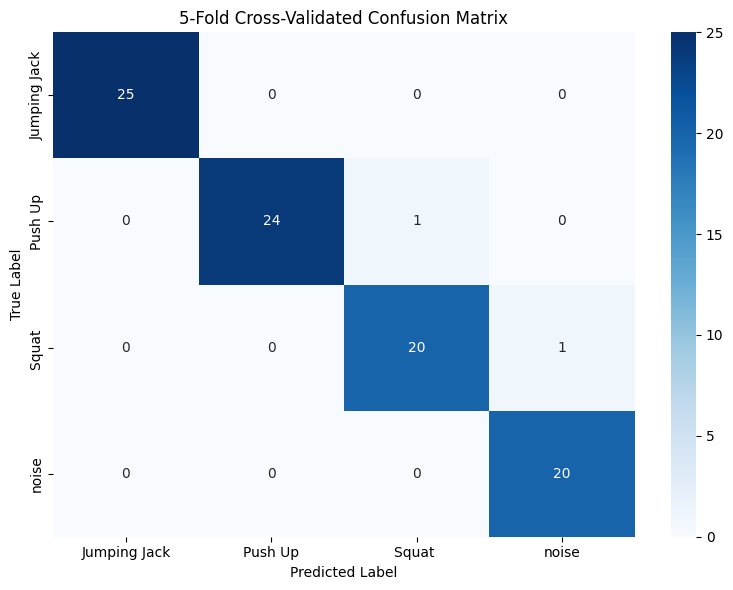

In [ ]:
if __name__ == "__main__":
    feature_csv = "/content/drive/MyDrive/2025NUS/main/imu_features_all_channels_original_filtered.xlsx"  # Must include file_id, activity, + 108 features
    model_file = "activity_model.pkl"
    train_and_save_model_from_csv(feature_csv, model_file)


    new_data_df = pd.read_excel("/content/drive/MyDrive/2025NUS/main/test_activity.xlsx")
    feature_cols = new_data_df.values
    reps, act = analyze_file_from_feature_rows(feature_cols, model_file)
    print(f"Predicted Reps: {reps}")
    print(f"Predicted Activity: {act}")

        # Cross-validation + Confusion Matrix
    run_cross_val_and_confusion(feature_csv, n_splits=5)

In [ ]:
# # === Rep Validator: Validate Each Detected Rep ===
# def validate_reps_from_segments(detected_segments, model_path):
#     """
#     detected_segments: list of feature vectors (each from one segmented rep)
#     model_path: path to your trained Random Forest model
#     """
#     clf = joblib.load(model_path)
#     valid_reps = 0

#     for idx, feature_row in enumerate(detected_segments):
#         feature_row = np.array(feature_row).reshape(1, -1)  # Ensure correct shape

#         predicted_activity = clf.predict(feature_row)[0]
#         prediction_proba = clf.predict_proba(feature_row)[0]
#         confidence = max(prediction_proba)

#         # Assuming any confident prediction is a valid rep
#         if confidence >= 0.6:  # Adjust threshold as needed
#             valid_reps += 1
#             print(f"Segment {idx+1}: VALID ({predicted_activity}), Confidence: {confidence:.2f}")
#         else:
#             print(f"Segment {idx+1}: REJECTED (Low Confidence: {confidence:.2f})")

#     print(f"\nFinal Corrected Rep Count: {valid_reps}")
#     return valid_reps
# # Example:
# # detected_segments = [feature_row1, feature_row2, ..., feature_rowN]
# # Each feature_row must be 108 features (no file_id, no activity column).

# model_file = "activity_model.pkl"

# final_rep_count = validate_reps_from_segments(detected_segments, model_file)
# print(f"Final Rep Count After Validation: {final_rep_count}")


#pipline:

###1. Raw IMU file (T × 12)
###2. segment_signal()  ← (peak detection)
###3. Rep segments: [rep1, rep2, ..., repN]
###4. Feature extraction: extract_features(rep_i) → 108 features each for rep.   per/rep
###5. Average features across N reps
###6. ML classifier → Predict activity
###7. Rep count = N


###72 file
###x5 rep/file
###x108 feature/rep
###activity:
###70% training + 30% testing
###jumping jack, 25 based on files
###squat,   25 based on files
###pushup,  25 based on files
### add noise
linear regresion?
peak detection +classification of this model,
try to see what percentage
if detect 7 segment, use model to tune to correct
it cant be perfect segments, have to use some fake or noise as an activity
